## Machine Learning Baseline: TF-IDF feature extraction, with Logistic Regression and Random Forest models

In this notebook, two traditional machine learning models (Logistic Regression and Random Forest) are trained and evaluated as a performance baseline for Phase 1. This baseline will later be compared against the fine-tuned XLM-RoBERTa transformer model.

The pipeline is:
1. Load processed splits from GCP
2. TF-IDF feature extraction
3. Train Logistic Regression and Random Forest with default parameters
4. Tune hyperparameters with Optuna
5. Evaluate tuned models on validation and test sets
6. Select baseline model and save to GCP

All metrics are reported as macro averages to give equal weight to both classes, as explained in the evaluation strategy defined after the exploratory data analysis, due to the moderate imbalance between the two classes.

In [1]:
# ========================================= #
# 04_baseline_ml.ipynb                      #
# ML Baseline: TF-IDF + Logistic Regression #
# and Random Forest with Optuna tuning      #
# ========================================= #

import numpy as np
import pandas as pd
from google.cloud import storage
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src')))

# Reproducibility
from utils import set_seed
SEED = 42
set_seed(SEED)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) #Reduces verbosity to only warnings or errors

print("Imports OK")
print(f"Optuna version: {optuna.__version__}")

Imports OK
Optuna version: 4.8.0


## 1. Load Processed Splits from GCP

The three splits (train, val, test) are loaded directly from the `sinodio-processed-data` bucket in Cloud Storage, where they were stored during preprocessing as Parquet files.

The `text_tfidf` column contains the deeply cleaned version of the text prepared specifically for traditional ML models during preprocessing.

In [2]:
# ============================== #
# Load processed splits from GCP #
# ============================== #

GCS_PROCESSED_BUCKET = 'sinodio-processed-data'

client = storage.Client()
bucket = client.bucket(GCS_PROCESSED_BUCKET)

def load_parquet_from_gcs(bucket, blob_name):
    blob = bucket.blob(blob_name)
    data = blob.download_as_bytes()  #downloads file from GCS into memory as a bytes object (binary content)
    return pd.read_parquet(pd.io.common.BytesIO(data)) #pd.io.common.BytesIO makes the bytes readable by Parquet

train = load_parquet_from_gcs(bucket, 'phase1/train.parquet')
val   = load_parquet_from_gcs(bucket, 'phase1/val.parquet')
test  = load_parquet_from_gcs(bucket, 'phase1/test.parquet')

print(f"Train: {train.shape}")
print(f"Val:   {val.shape}")
print(f"Test:  {test.shape}")

print(f"\nColumns: {train.columns.tolist()}")
print(f"\nNull values:\n{train.isnull().sum()}")

Train: (41245, 5)
Val:   (7279, 5)
Test:  (8564, 5)

Columns: ['text', 'label', 'source', 'text_clean', 'text_tfidf']

Null values:
text          0
label         0
source        0
text_clean    0
text_tfidf    0
dtype: int64


## 2. TF-IDF Feature Extraction

TF-IDF (Term Frequency - Inverse Document Frequency) represents each text as a vector 
of weighted frequency of each token. Tokens that are frequent in one text but rare across 
the overall dataset receive higher weights, making them more likely to carry a signal useful for the classifier to tell the two classes apart (unlike common terms which would be just as frequent in both classes).

Key decisions:
- `ngram_range=(1,3)`: unigrams, bigrams and trigrams are included to capture combinations of words or expressions relevant to hate speech, such as "puta zorra" or "inmigrantes de mierda"
- `max_features=150_000`: vocabulary capped at 150k to manage memory with trigrams included
- `min_df=2`: tokens appearing in only one document are excluded to reduce noise
- `sublinear_tf=True`: log normalization lowers the effect of extreme term repetition within a text

The vectorizer is fitted **only on the training set** and then applied to val and test,
to avoid data leakage.

The 20 most frequent bigrams and trigrams per class are plotted to visualize these most frequent combinations.

Note: lemmatization was not applied in preprocessing, which means different forms of the 
same word appear as separate tokens. This is a known limitation of this traditional ML pipeline and a clear avenue for future improvement.

X_train: (41245, 42065)
X_val:   (7279, 42065)
X_test:  (8564, 42065)


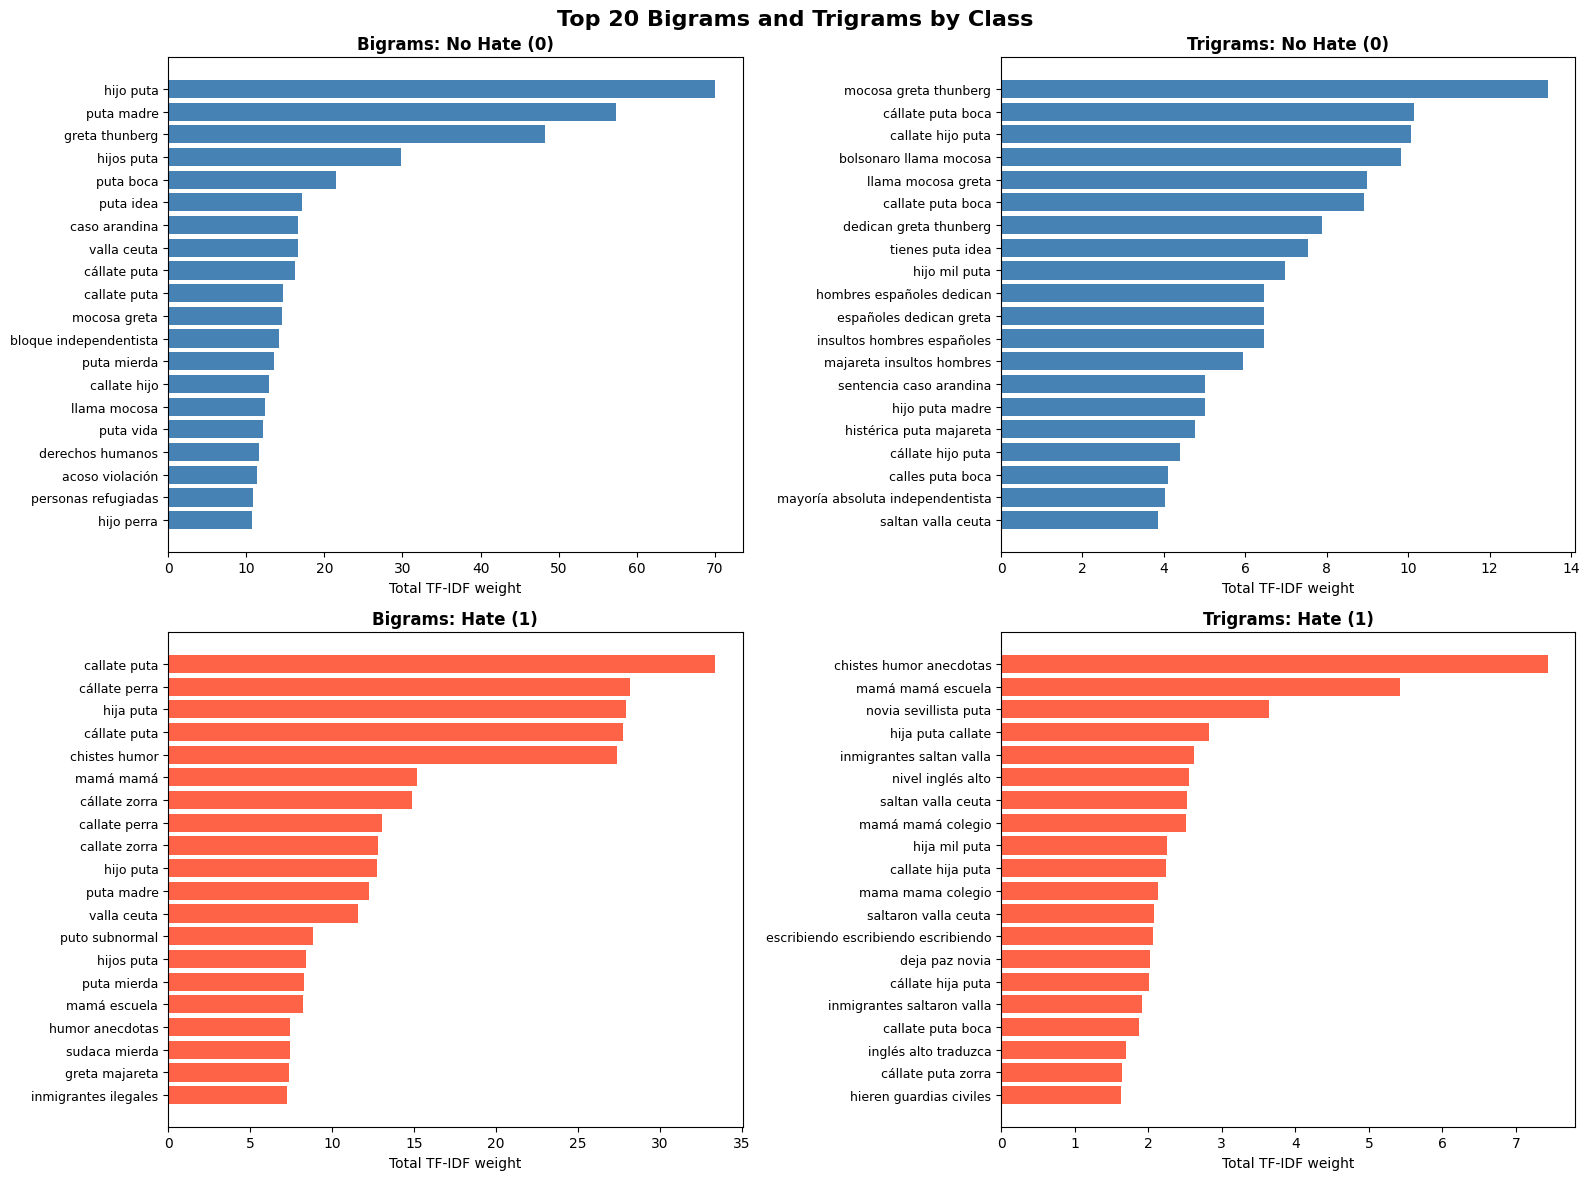


Plot saved to reports/tfidf_ngrams_by_class.png


In [4]:
# ========================= #
# TF-IDF Feature Extraction #
# ========================= #

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Fit TF-IDF on training set only ---
tfidf = TfidfVectorizer(
    max_features=150_000,
    ngram_range=(1, 3),
    min_df=2,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train['text_tfidf'])
X_val   = tfidf.transform(val['text_tfidf'])
X_test  = tfidf.transform(test['text_tfidf'])

y_train = train['label'].values
y_val   = val['label'].values
y_test  = test['label'].values

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

# --- Extract most frequent bigrams and trigrams by class ---
feature_names = np.array(tfidf.get_feature_names_out())

def get_top_ngrams(X, y, label, ngram_size, n=20):
    """Return top n ngrams of a given size for a given class."""
    X_class = X[y == label]
    freqs   = np.asarray(X_class.sum(axis=0)).flatten()
    mask    = np.array([len(f.split()) == ngram_size for f in feature_names])
    freqs_filtered = freqs * mask
    top_idx = freqs_filtered.argsort()[-n:][::-1]
    return feature_names[top_idx], freqs_filtered[top_idx]

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 20 Bigrams and Trigrams by Class', fontsize=16, fontweight='bold')

configs = [
    (0, 2, 'Bigrams: No Hate (0)'),
    (0, 3, 'Trigrams: No Hate (0)'),
    (1, 2, 'Bigrams: Hate (1)'),
    (1, 3, 'Trigrams: Hate (1)'),
]

for ax, (label, ngram_size, title) in zip(axes.flatten(), configs):
    terms, freqs = get_top_ngrams(X_train, y_train, label, ngram_size)
    ax.barh(terms[::-1], freqs[::-1], color='steelblue' if label == 0 else 'tomato')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Total TF-IDF weight')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('../../reports/tfidf_ngrams_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to reports/tfidf_ngrams_by_class.png")

**Observations from the bigrams and trigrams plots:**

*No Hate (0):*

* "hijo puta" and "puta madre" dominate the bigrams, which is consistent with what was mentioned during the exploratory data analysis about Chilean Spanish; they are common colloquial expressions that don't necessarily imply hate
* "greta thunberg", "caso arandina", "bloque independentista" confirm the presence of political/news content in the non-hate class
* "derechos humanos", "personas refugiadas" are representative of discussion with facts about vulnerable groups without hateful intent

*Hate (1):*

* The bigrams are much more clearly offensive and contain direct insults such as "cállate puta/perra/zorra"
* "inmigrantes saltan valla" and "inmigrantes ilegales" confirm the xenophobic content from DETOXIS
* "chistes humor (anecdotas)" or "mamá mamá (escuela)" in the hate bigrams and trigrams are most likely from HAHA, as they are written with a joke or irony structure
* Repetitions such as "escribiendo escribiendo escribiendo" seem to be some sort of cynical artifact specific of irony in hate speech

## 3. Logistic Regression with default parameters

Logistic Regression is trained first with default parameters to establish a reference point
before tuning:

* `class_weight='balanced'` is used to compensate for the class imbalance(69% no hate / 31% hate)
* `max_iter=1000` raises the maximum number of iterations to 1000 (instead of the default 100) to increase the chance of convergence, given that we have high-dimensional TF-IDF features.

In [5]:
# =================== #
# Logistic Regression #
# Default parameters  #
# =================== #

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_default = LogisticRegression(
    class_weight='balanced',
    random_state=SEED,
    max_iter=1000
)

lr_default.fit(X_train, y_train)

y_pred_val_lr = lr_default.predict(X_val)

print("Logistic Regression — Default parameters")
print("Validation set results:")
print(classification_report(y_val, y_pred_val_lr, target_names=['No Hate', 'Hate']))

Logistic Regression — Default parameters
Validation set results:
              precision    recall  f1-score   support

     No Hate       0.85      0.81      0.83      5034
        Hate       0.62      0.68      0.65      2245

    accuracy                           0.77      7279
   macro avg       0.74      0.75      0.74      7279
weighted avg       0.78      0.77      0.78      7279



## 4. Random Forest with default parameters

Random Forest is trained with default parameters for comparison with Logistic Regression:
* `n_jobs=-1` uses all available CPU cores since Random Forest trains trees in parallel,
which is important given the high dimensionality of the TF-IDF feature space.

In [6]:
# ================== #
# Random Forest      #
# Default parameters #
# ================== #

from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_default.fit(X_train, y_train)

y_pred_val_rf = rf_default.predict(X_val)

print("Random Forest — Default parameters")
print("Validation set results:")
print(classification_report(y_val, y_pred_val_rf, target_names=['No Hate', 'Hate']))

Random Forest — Default parameters
Validation set results:
              precision    recall  f1-score   support

     No Hate       0.79      0.93      0.85      5034
        Hate       0.73      0.46      0.57      2245

    accuracy                           0.78      7279
   macro avg       0.76      0.69      0.71      7279
weighted avg       0.78      0.78      0.77      7279



## 5. Logistic Regression with Hyperparameter Tuning (Optuna)

Optuna searches for the best combination of regularization strength (`C`) and solver.
The objective function maximizes macro F1 on the validation set.
We are using 50 trials with a timeout of 10 minutes (600 seconds).

In [9]:
# ================================== #
# Optuna tuning: Logistic Regression #
# ================================== #

import optuna
from sklearn.metrics import f1_score

def objective_lr(trial):
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
    
    model = LogisticRegression(
        C=C,
        solver=solver,
        class_weight='balanced',
        random_state=SEED,
        max_iter=1000
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro')

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50, timeout=600)

print("Logistic Regression best parameters:")
print(study_lr.best_params)
print(f"Best macro F1 (val): {study_lr.best_value:.4f}")

Logistic Regression best parameters:
{'C': 1.639032087464018, 'solver': 'saga'}
Best macro F1 (val): 0.7430


## 6. Random Forest with Hyperparameter Tuning (Optuna)

Optuna searches over tree depth, number of estimators, and feature sampling strategy.
The objective function maximizes **macro F1** on the validation set, in order to give equal weight to both classes.
Here we will be using 30 trials (as it is expected to take much longer than Logistic Regression) with a timeout of 60 minutes (3600 seconds).

In [10]:
# ============================ #
# Optuna tuning: Random Forest #
# ============================ #

def objective_rf(trial):
    n_estimators    = trial.suggest_int('n_estimators', 100, 500)
    max_depth       = trial.suggest_categorical('max_depth', [10, 20, 30, 50, None])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro')

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30, timeout=3600)

print("Random Forest best parameters:")
print(study_rf.best_params)
print(f"Best macro F1 (val): {study_rf.best_value:.4f}")

Random Forest best parameters:
{'n_estimators': 176, 'max_depth': None, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2'}
Best macro F1 (val): 0.7402


## 7. Evaluation of Tuned Models

Both ML models (Logistic Regression and Random Forest) are trained again using their best parameters, and they are evaluated on both the 
validation and test sets. Evaluating on both sets helps to confirm that the performance 
generalizes well and did not overfit on the validation set during tuning.

In [11]:
# ========================== #
# Evaluation of tuned models #
# Validation and Test sets   #
# ========================== #

# --- Train tuned models with best parameters ---
lr_tuned = LogisticRegression(
    **study_lr.best_params,    # "**" = Python's unpacking operator (directly unpacks the dictionary of best params)
    class_weight='balanced',
    random_state=SEED,
    max_iter=1000
)
lr_tuned.fit(X_train, y_train)

rf_tuned = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

# --- Evaluate on validation and test sets ---
results = {}

for model_name, model in [('Logistic Regression', lr_tuned), ('Random Forest', rf_tuned)]:
    for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = model.predict(X)
        results[f'{model_name}_{split_name}'] = {
            'accuracy':  accuracy_score(y, y_pred),
            'precision': precision_score(y, y_pred, average='macro'),
            'recall':    recall_score(y, y_pred, average='macro'),
            'f1_macro':  f1_score(y, y_pred, average='macro')
        }
        print(f"\n{model_name} — {split_name.upper()}")
        print(classification_report(y, y_pred, target_names=['No Hate', 'Hate']))

# --- Summary table ---
print("\n" + "="*65)
print(f"{'Model':<22} {'Split':<6} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("="*65)
for key, metrics in results.items():
    model_name, split = key.rsplit('_', 1)
    print(f"{model_name:<22} {split:<6} "
          f"{metrics['accuracy']:>6.3f} "
          f"{metrics['precision']:>6.3f} "
          f"{metrics['recall']:>6.3f} "
          f"{metrics['f1_macro']:>6.3f}")
print("="*65)


Logistic Regression — VAL
              precision    recall  f1-score   support

     No Hate       0.85      0.82      0.83      5034
        Hate       0.62      0.68      0.65      2245

    accuracy                           0.78      7279
   macro avg       0.74      0.75      0.74      7279
weighted avg       0.78      0.78      0.78      7279


Logistic Regression — TEST
              precision    recall  f1-score   support

     No Hate       0.86      0.81      0.83      5922
        Hate       0.62      0.70      0.66      2642

    accuracy                           0.78      8564
   macro avg       0.74      0.75      0.75      8564
weighted avg       0.78      0.78      0.78      8564


Random Forest — VAL
              precision    recall  f1-score   support

     No Hate       0.84      0.84      0.84      5034
        Hate       0.64      0.64      0.64      2245

    accuracy                           0.78      7279
   macro avg       0.74      0.74      0.74      727

## 8. Save Model and Results

The selected baseline model (Logistic Regression) and its TF-IDF vectorizer are saved 
to the `sinodio-models` GCS bucket, since they are both needed for making predictions on new data: the vectorizer 
transforms raw text into TF-IDF features, and the model classifies the features.

Results for both models are written to BigQuery as `baseline_ml_results` in the 
`sinodio_results` dataset, with a `selected` flag marking Logistic Regression as the 
chosen baseline.

In [13]:
# ========================================= #
# Save results to BigQuery and model to GCS #
# ========================================= #

import joblib
from google.cloud import bigquery, storage
import datetime

# --- Save tuned LR model locally ---
model_dir = '../../models'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(lr_tuned, f'{model_dir}/lr_baseline.joblib')
joblib.dump(tfidf,    f'{model_dir}/tfidf_vectorizer.joblib')
print("Models saved locally.")

# --- Upload to sinodio-models bucket ---
models_bucket = client.bucket('sinodio-models')

for filename in ['lr_baseline.joblib', 'tfidf_vectorizer.joblib']:
    blob = models_bucket.blob(f'phase1/{filename}')
    blob.upload_from_filename(f'{model_dir}/{filename}')
    print(f"Uploaded {filename} → gs://sinodio-models/phase1/{filename}")

# --- Write results to BigQuery ---
bq_client = bigquery.Client()
table_id  = 'project-5c89dcac-34cb-453d-bd7.sinodio_results.baseline_ml_results'

schema = [
    bigquery.SchemaField('model',      'STRING'),
    bigquery.SchemaField('split',      'STRING'),
    bigquery.SchemaField('accuracy',   'FLOAT'),
    bigquery.SchemaField('precision',  'FLOAT'),
    bigquery.SchemaField('recall',     'FLOAT'),
    bigquery.SchemaField('f1_macro',   'FLOAT'),
    bigquery.SchemaField('selected',   'BOOLEAN'),
    bigquery.SchemaField('created_at', 'STRING'),
]

table = bigquery.Table(table_id, schema=schema)
table = bq_client.create_table(table, exists_ok=True)

rows = []
for key, metrics in results.items():
    model_name, split = key.rsplit('_', 1)
    rows.append({
        'model':      model_name,
        'split':      split,
        'accuracy':   round(metrics['accuracy'], 4),
        'precision':  round(metrics['precision'], 4),
        'recall':     round(metrics['recall'], 4),
        'f1_macro':   round(metrics['f1_macro'], 4),
        'selected':   model_name == 'Logistic Regression',
        'created_at': datetime.datetime.now(datetime.timezone.utc).isoformat()
    })

errors = bq_client.insert_rows_json(table_id, rows)

if not errors:
    print(f"\nResults written to BigQuery: {table_id}")
    for row in rows:
        print(f"  {row['model']:<22} {row['split']:<6} F1: {row['f1_macro']} selected: {row['selected']}")
else:
    print(f"BigQuery insert errors: {errors}")

Models saved locally.
Uploaded lr_baseline.joblib → gs://sinodio-models/phase1/lr_baseline.joblib
Uploaded tfidf_vectorizer.joblib → gs://sinodio-models/phase1/tfidf_vectorizer.joblib

Results written to BigQuery: project-5c89dcac-34cb-453d-bd7.sinodio_results.baseline_ml_results
  Logistic Regression    val    F1: 0.743 selected: True
  Logistic Regression    test   F1: 0.7453 selected: True
  Random Forest          val    F1: 0.7402 selected: False
  Random Forest          test   F1: 0.744 selected: False


## Summary of Baseline Machine Learning Results

Two models were trained and tuned with Optuna on TF-IDF features (unigrams, bigrams, trigrams, max 150k features):

| Model               | Split | Accuracy | Precision | Recall | F1 Macro |
|---------------------|-------|----------|-----------|--------|----------|
| Logistic Regression | val   | 0.776    | 0.738     | 0.749  | 0.743    |
| Logistic Regression | test  | 0.775    | 0.739     | 0.754  | 0.745    |
| Random Forest       | val   | 0.778    | 0.740     | 0.741  | 0.740    |
| Random Forest       | test  | 0.782    | 0.745     | 0.743  | 0.744    |

**Selected baseline: Logistic Regression** (C=1.607, solver=liblinear)

Justification: very slightly higher F1 Macro (most important metric given the class imbalance) and significantly higher recall on the hate class (0.70 vs 0.64), prioritizing detection of hate speech over precision. Computational efficiency (time) of Logistic Regression
is also a practical advantage over Random Forest for future retraining or potential higher-dimensional TF-IDF feature space.

Both the tuned model and TF-IDF vectorizer are saved to `gs://sinodio-models/phase1/`.
Results are written to BigQuery as `baseline_ml_results` in the `sinodio_results` dataset.